# 01 · Exploratory Data Analysis
Report section: *Dataset description* + *EDA* (mandatory, brief item c).

Covers class balance (C1), the red-corner confound (C2), and feature distributions. Correlations + leakage sanity check (C3) still to come.

In [1]:
# Make src/ importable from notebooks/
import sys, os; sys.path.insert(0, os.path.abspath('..'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.data.load import load_clean
from src.plotting import save_fig

## 1. Load data
`data/raw/...` (see `docs/DATASETS.md`). Leakage-safe build lives in `src/data/`.


In [2]:
df, y = load_clean()
winner = y.str.split('-').str[0]      # 'Red' / 'Blue'
method = y.str.split('-').str[1]      # 'KO' / 'SUB' / 'DEC'
print(f'{len(df)} fights, {y.nunique()} classes, {df.shape[1]} raw columns')
y.value_counts()

6911 fights, 6 classes, 111 raw columns


Red-DEC     1974
Blue-DEC    1454
Red-KO      1242
Blue-KO      981
Red-SUB      775
Blue-SUB     485
Name: count, dtype: int64

## 2. Class balance & target
Winner / method-of-victory distribution; weight-class & stance breakdowns.


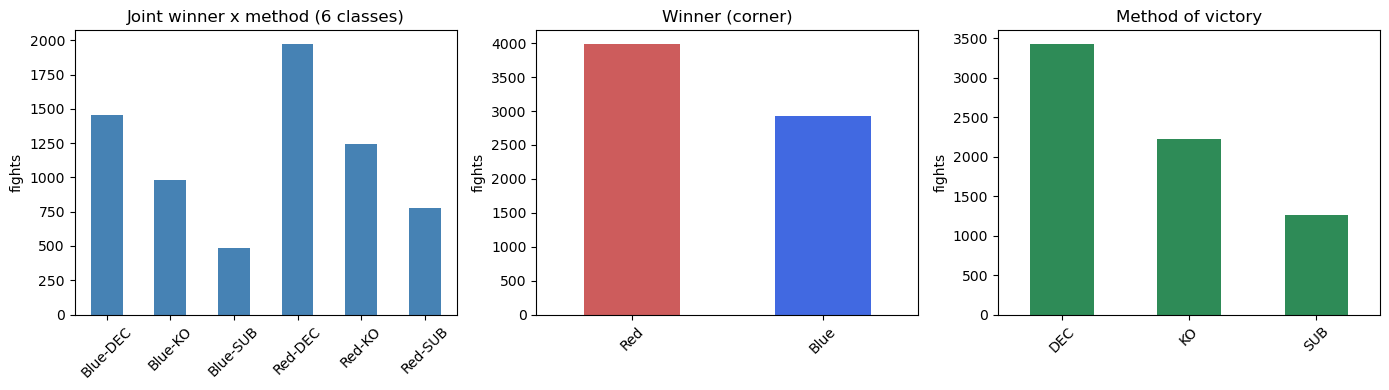

imbalance: Red-DEC (1974) vs Blue-SUB (485) = 4.1x
red wins 57.7% of fights (the skew we symmetrize away for modelling)


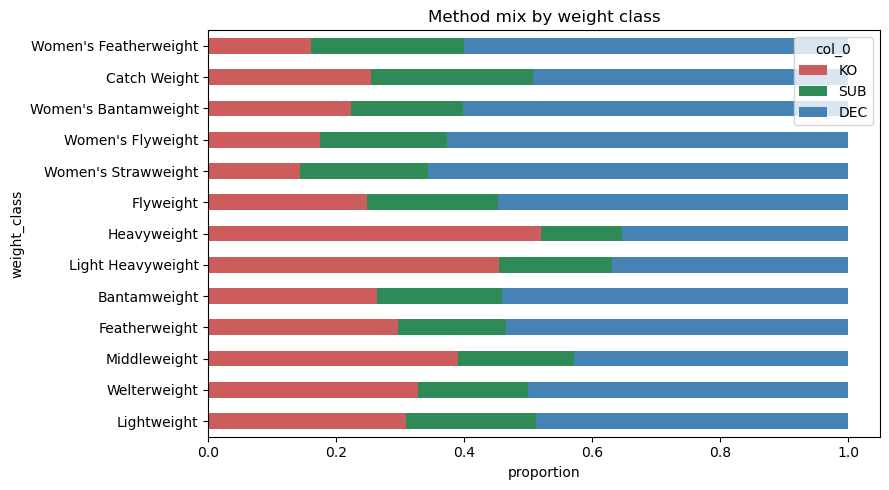

In [3]:
# --- class balance: the 6 joint classes, plus the winner and method views ---
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
y.value_counts().sort_index().plot.bar(ax=ax[0], color='steelblue', title='Joint winner x method (6 classes)')
winner.value_counts().plot.bar(ax=ax[1], color=['indianred', 'royalblue'], title='Winner (corner)')
method.value_counts().plot.bar(ax=ax[2], color='seagreen', title='Method of victory')
for a in ax:
    a.tick_params(axis='x', rotation=45); a.set_ylabel('fights')
plt.tight_layout(); save_fig('class_balance'); plt.show()

vc = y.value_counts()
print(f'imbalance: {vc.idxmax()} ({vc.max()}) vs {vc.idxmin()} ({vc.min()}) = {vc.max()/vc.min():.1f}x')
print(f'red wins {(winner == "Red").mean():.1%} of fights (the skew we symmetrize away for modelling)')

# --- method mix by weight class: are heavier divisions more KO-prone? ---
order = df['weight_class'].value_counts().index
ct = pd.crosstab(df['weight_class'], method, normalize='index')[['KO', 'SUB', 'DEC']].reindex(order)
ct.plot.barh(stacked=True, figsize=(9, 5), color=['indianred', 'seagreen', 'steelblue'],
             title='Method mix by weight class')
plt.xlabel('proportion'); plt.tight_layout(); save_fig('method_by_weightclass'); plt.show()

## 3. The red-corner confound (the differentiator)
Red wins ~58% of fights, but "red" is systematically assigned to the favourite. We show the raw red win-rate, then condition on who the market favours: once we know the favourite, the corner colour adds almost nothing. This is why we **symmetrize corners** for modelling, and measure an "always-red" baseline only on the original corners.

raw P(red wins)              = 0.577
red is the favourite in        59.5% of fights
P(red wins | red favourite)   = 0.696
P(red wins | blue favourite)  = 0.404
P(favourite wins, any corner) = 0.655


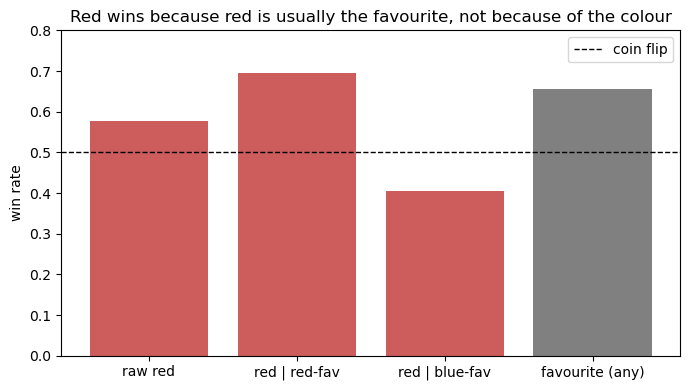

In [4]:
# raw red advantage
red_wr = (winner == 'Red').mean()

# 'favourite' = the corner with the more negative American moneyline
red_fav = df['R_odds'] < df['B_odds']
p_red_red_fav  = (winner[red_fav]  == 'Red').mean()
p_red_blue_fav = (winner[~red_fav] == 'Red').mean()
fav_won = (red_fav & (winner == 'Red')) | (~red_fav & (winner == 'Blue'))
fav_wr = fav_won.mean()

print(f'raw P(red wins)              = {red_wr:.3f}')
print(f'red is the favourite in        {red_fav.mean():.1%} of fights')
print(f'P(red wins | red favourite)   = {p_red_red_fav:.3f}')
print(f'P(red wins | blue favourite)  = {p_red_blue_fav:.3f}')
print(f'P(favourite wins, any corner) = {fav_wr:.3f}')

bars = {'raw red': red_wr, 'red | red-fav': p_red_red_fav,
        'red | blue-fav': p_red_blue_fav, 'favourite (any)': fav_wr}
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(bars.keys(), bars.values(), color=['indianred', 'indianred', 'indianred', 'grey'])
ax.axhline(0.5, ls='--', c='k', lw=1, label='coin flip')
ax.set_ylabel('win rate'); ax.set_ylim(0, 0.8); ax.legend()
ax.set_title('Red wins because red is usually the favourite, not because of the colour')
plt.tight_layout(); save_fig('red_corner_confound'); plt.show()

## 4. Feature distributions
Spread of the key pre-fight difference features (red - blue). Correlations + the leakage sanity check are C3 (still to do).

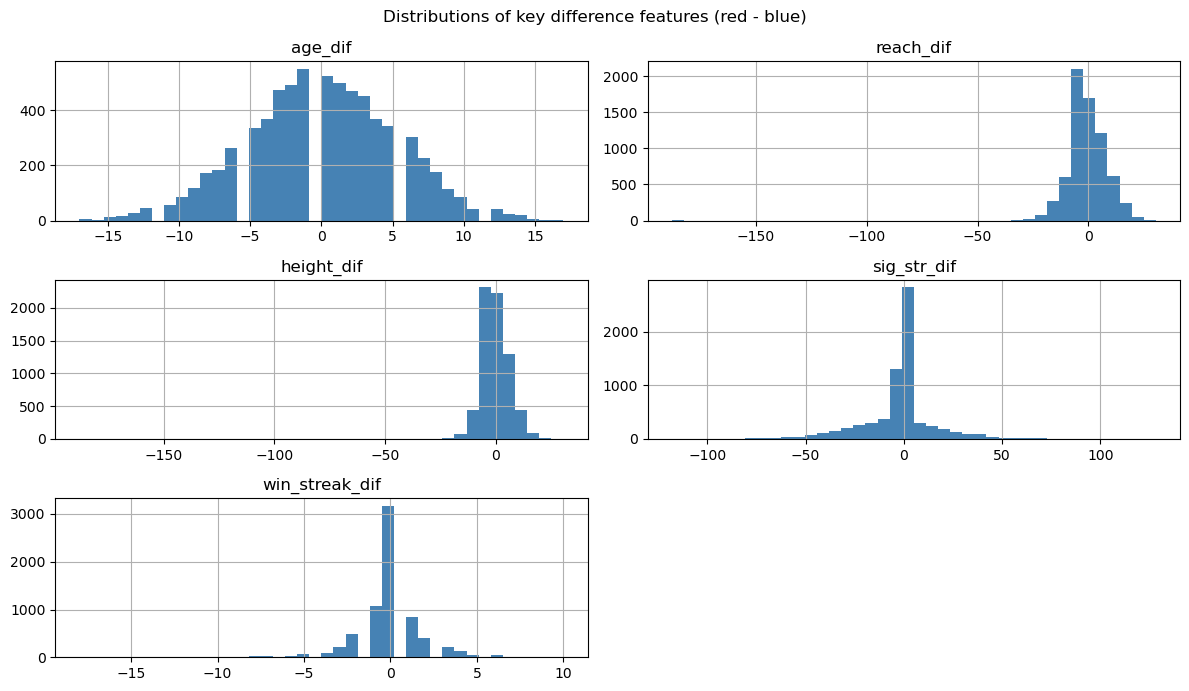

In [5]:
# distributions of a few key pre-fight difference features (red - blue)
pref = ['age_dif', 'reach_dif', 'height_dif', 'sig_str_dif', 'td_dif', 'win_streak_dif']
dif_cols = [c for c in df.columns if c.endswith('_dif')]
feats = [c for c in pref if c in dif_cols] or dif_cols[:6]
df[feats].hist(figsize=(12, 7), bins=40, color='steelblue')
plt.suptitle('Distributions of key difference features (red - blue)')
plt.tight_layout(); save_fig('feature_distributions'); plt.show()

# C3 (correlation heatmap + leakage sanity: debut rows should have empty priors) still to do.

## 5. Correlations & leakage sanity check (C3)
Multicollinearity among the key difference features (matters for LDA/QDA), then a pre-fight integrity check: career aggregates must come from prior fights only, so debutants should have empty priors.

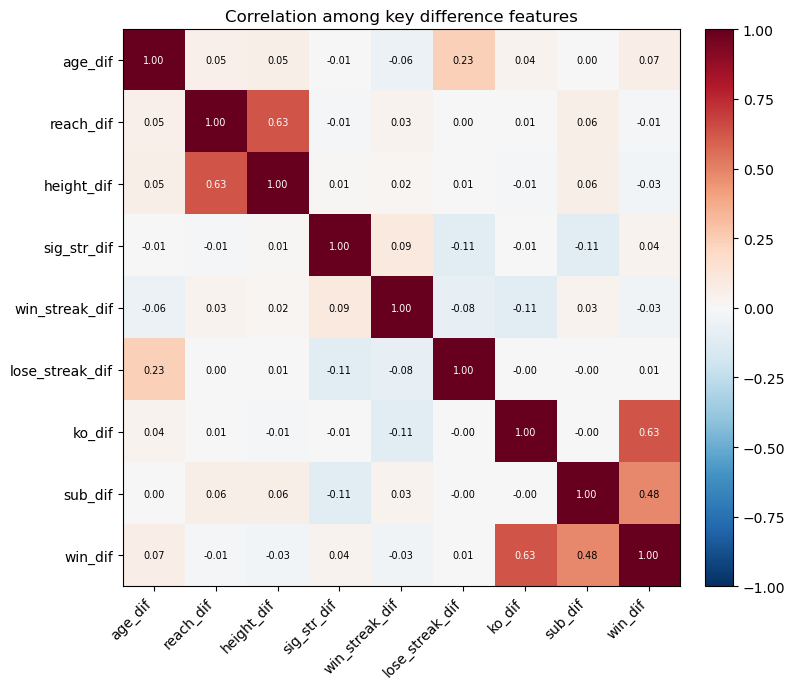

In [6]:
# correlation among the key difference features (a multicollinearity check for LDA/QDA)
key = ['age_dif', 'reach_dif', 'height_dif', 'sig_str_dif', 'td_dif',
       'win_streak_dif', 'lose_streak_dif', 'ko_dif', 'sub_dif', 'win_dif']
key = [c for c in key if c in df.columns]
corr = df[key].corr()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(key))); ax.set_xticklabels(key, rotation=45, ha='right')
ax.set_yticks(range(len(key))); ax.set_yticklabels(key)
for i in range(len(key)):
    for j in range(len(key)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black')
fig.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title('Correlation among key difference features')
plt.tight_layout(); save_fig('feature_correlations'); plt.show()

In [7]:
# Pre-fight integrity: a fighter's career-average stats must come from PRIOR fights only,
# so a debutant (no prior UFC record) should have empty priors. If the current bout leaked
# in, debutants would already show stats.
for pref in ['R', 'B']:
    avg_cols = [c for c in df.columns if 'avg' in c.lower() and c.startswith(f'{pref}_')]
    deb = (df[f'{pref}_wins'] + df[f'{pref}_losses']) == 0
    nan_deb = df.loc[deb, avg_cols].isna().mean().mean()
    nan_exp = df.loc[~deb, avg_cols].isna().mean().mean()
    print(f'{pref} corner: {deb.sum():4d} debutants | career-avg missing: '
          f'debut {nan_deb:.0%} vs experienced {nan_exp:.0%}')

print('\nExperienced fighters have complete priors (0% missing); debutants are mostly empty')
print('=> aggregates are genuinely PRE-fight (the current bout is not baked in). Leakage-safe.')
print('(the ~25% of UFC-debutants that do show stats had pre-UFC fights seeding their averages.)')

R corner:  431 debutants | career-avg missing: debut 75% vs experienced 0%
B corner: 1071 debutants | career-avg missing: debut 71% vs experienced 0%

Experienced fighters have complete priors (0% missing); debutants are mostly empty
=> aggregates are genuinely PRE-fight (the current bout is not baked in). Leakage-safe.
(the ~25% of UFC-debutants that do show stats had pre-UFC fights seeding their averages.)
